<a href="https://colab.research.google.com/github/saraxfl/Notebook/blob/main/collab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, matthews_corrcoef,)

RANDOM_STATE = 42
pd.set_option('display.width', 130)
plt.rcParams.update({"figure.dpi":110, "font.size":10})
fmt = lambda v: f"{v:.4f}"
print("ready")

ready


Before computing a songle metric, answer one question : wich class is positive?

In [11]:
data=load_breast_cancer()
print("target_names: ", list (data.target_names))
for value,name in enumerate(data.target_names):
  n = (data.target == value).sum()
  print(f"Target = {value} -> {name: <10s} {n:>4d} cases ({n / len(data.target):.1%})")

target_names:  [np.str_('malignant'), np.str_('benign')]
Target = 0 -> malignant   212 cases (37.3%)
Target = 1 -> benign      357 cases (62.7%)


target = 1 is malignant, target = 0 bening
positive = malignant = 1

In [12]:
x = data.data
y = (data.target == 0).astype(int) #1 = malignant, the class we care about
CLASSES = ["bening", "malignant"]
print(f"positive (malignanat):{y.sum():>4d} prevalence {y.mean():.1%}")
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.30,random_state=RANDOM_STATE, stratify=y
    )
print(f"\n train {X_train.shape[0]} rows | test {X_test.shape[0]} rows")
print(f"stratify keeps the prevalence: train {y_train.mean():.3f} | test {y_test.mean():.3f}")

positive (malignanat): 212 prevalence 37.3%

 train 398 rows | test 171 rows
stratify keeps the prevalence: train 0.372 | test 0.374


#Scale the features - not optional here

In [13]:
ranges = pd.DataFrame({"min": x.min(axis=0), "max": x.max(axis=0)},
                      index=data.feature_names)
print(" a few features ranges -- four orders of magnitude apart:")
print(ranges.loc[["mean fractal dimension", "mean smoothness", "mean radius",
                  "mean perimeter", "worst area"]].to_string(float_format=lambda v: f"{v:10.4f}"))

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
    ),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM (RBF)": make_pipeline(
        StandardScaler(), SVC(probability=True, random_state=RANDOM_STATE)
    ),
}

for name, m in models.items():
    m.fit(X_train, y_train)

# Escalar datos
raw_svm = SVC(random_state=RANDOM_STATE).fit(X_train, y_train)
print(f"\n SVM without scaling: accuracy {accuracy_score(y_test, raw_svm.predict(X_test)):.4f}")
print(f"SVM with scaling: accuracy {accuracy_score(y_test, models['SVM (RBF)'].predict(X_test)):.4f}")
print("same algorithm. The gap is preprocessing, not the model")

 a few features ranges -- four orders of magnitude apart:
                              min        max
mean fractal dimension     0.0500     0.0974
mean smoothness            0.0526     0.1634
mean radius                6.9810    28.1100
mean perimeter            43.7900   188.5000
worst area               185.2000  4254.0000

 SVM without scaling: accuracy 0.9006
SVM with scaling: accuracy 0.9591
same algorithm. The gap is preprocessing, not the model


#1. Every predict falls into one of our boxes

In [14]:
model = models["Logistic Regression"]
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred) # row - truth , columns - prediction
tn, fp, fn, tp = cm.ravel()
print("scikit-learn puts truth on the rows and prediction on the columns")
print(pd.DataFrame(cm,
                   index=[f"actual {c}" for c in CLASSES],
                   columns=[f"predicted {c}" for c in CLASSES]))
print(f"/n TP = {tp:>3d} malignant, correctly caught")
print(f"/n FP = {fp:>3d} benign, false alarm")
print(f"/n FN = {fn:>3d} malignant, imissed")
print(f"/n TN = {tn:>3d} benign, correctly cleared")

scikit-learn puts truth on the rows and prediction on the columns
                  predicted bening  predicted malignant
actual bening                  106                    1
actual malignant                 4                   60
/n TP =  60 malignant, correctly caught
/n FP =   1 benign, false alarm
/n FN =   4 malignant, imissed
/n TN = 106 benign, correctly cleared


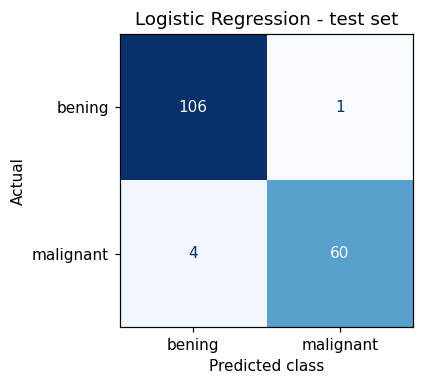

In [15]:
fig, ax = plt.subplots(figsize=(4.3, 3.6))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression - test set")
ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

#2 Accuracy and where it breaks

In [16]:
print(f"accuracy from the matrix: {(tp +tn) / cm.sum():.4f}")
print(f"accuracy from sklearn: {accuracy_score(y_test, y_pred):.4f}")

accuracy from the matrix: 0.9708
accuracy from sklearn: 0.9708


The baselines acurracy hides

In [17]:
from sklearn.datasets import make_classification
X_imb, y_imb = make_classification(
    n_samples=20_000, n_features=20, n_informative=6, n_redundant=2,
    weights=[0.99, 0.01], flip_y = 0.01, class_sep=0.9, random_state=RANDOM_STATE
)
x_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=RANDOM_STATE, stratify=y_imb
)
print(f"synthetic fraud dat: {len(y_imb):,} rows, prevalence {y_imb.mean():.2%}")
print(f"train {len(y_imb_tr):,} rows ({y_imb_tr.sum()} frauds)")
print(f"test {len(y_imb_te):,} rows ({y_imb_te.sum()} frauds)")

synthetic fraud dat: 20,000 rows, prevalence 1.45%
train 14,000 rows (203 frauds)
test 6,000 rows (87 frauds)
